# Task 4: Recommendation System
**Elite Tech Intern — Machine Learning Internship**

**Objective:** Build a recommendation system using Collaborative Filtering / Matrix Factorization.

**Dataset:** A synthetic user-item ratings matrix (movies) is generated below so the notebook runs
end-to-end with no external downloads. To use a real dataset, replace the data-loading cell with
e.g. the MovieLens dataset loaded from a CSV.

**Approach:** Matrix Factorization via Gradient Descent (implemented from scratch with NumPy) to learn
latent user and item factors — the same core idea behind SVD-based recommenders.

**Deliverable:** This notebook — showcasing recommendation results and evaluation metrics (RMSE).


In [1]:
# ----------------------------------------------------
# 1. Import required libraries
# ----------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Create a synthetic user-item ratings dataset

In [2]:
n_users = 50
n_movies = 30

movie_titles = [f"Movie_{i+1}" for i in range(n_movies)]

# Simulate 'true' latent preferences so ratings have realistic underlying structure
n_true_factors = 5
true_user_factors = np.random.normal(0, 1, (n_users, n_true_factors))
true_item_factors = np.random.normal(0, 1, (n_movies, n_true_factors))
true_ratings = true_user_factors @ true_item_factors.T

# Scale to a 1-5 star range and add noise
true_ratings = 3 + (true_ratings - true_ratings.mean()) / true_ratings.std() * 1.2
true_ratings += np.random.normal(0, 0.3, true_ratings.shape)
true_ratings = np.clip(true_ratings, 1, 5)

# Simulate sparsity: each user only rates ~40% of movies
mask = np.random.rand(n_users, n_movies) < 0.4
ratings_matrix = np.where(mask, true_ratings, np.nan)

ratings_df = pd.DataFrame(ratings_matrix,
                           index=[f"User_{i+1}" for i in range(n_users)],
                           columns=movie_titles)

print(f"Ratings matrix shape: {ratings_df.shape}")
print(f"Observed ratings: {mask.sum()} / {n_users * n_movies} "
      f"({mask.sum() / (n_users * n_movies):.1%} filled)")
ratings_df.round(1).head()


Ratings matrix shape: (50, 30)
Observed ratings: 608 / 1500 (40.5% filled)


,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_21,Movie_22,Movie_23,Movie_24,Movie_25,Movie_26,Movie_27,Movie_28,Movie_29,Movie_30
User_1,4.0,NaN,1.0,NaN,NaN,NaN,NaN,3.0,NaN,3.7,...,3.8,3.6,3.2,3.4,4.3,NaN,NaN,4.9,NaN,2.8
User_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.1,...,4.8,NaN,4.1,NaN,4.4,NaN,NaN,3.4,NaN,NaN
User_3,NaN,NaN,NaN,3.2,4.1,3.0,NaN,4.2,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
User_4,4.0,NaN,NaN,NaN,NaN,3.1,1.5,4.2,NaN,1.4,...,NaN,3.8,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
User_5,1.0,NaN,NaN,2.2,4.6,2.9,NaN,NaN,2.2,NaN,...,3.5,1.8,NaN,NaN,NaN,NaN,3.2,NaN,1.0,NaN


## 3. Prepare train/test split of observed ratings

In [3]:
# Get indices of all observed (non-NaN) ratings
observed_idx = np.argwhere(~np.isnan(ratings_matrix))
np.random.shuffle(observed_idx)

split = int(0.8 * len(observed_idx))
train_idx = observed_idx[:split]
test_idx = observed_idx[split:]

# Build a training matrix (test entries hidden with NaN)
train_matrix = ratings_matrix.copy()
for i, j in test_idx:
    train_matrix[i, j] = np.nan

print(f"Training ratings: {len(train_idx)}")
print(f"Test ratings:     {len(test_idx)}")


Training ratings: 486
Test ratings:     122


## 4. Matrix Factorization via Gradient Descent

In [4]:
def train_matrix_factorization(train_matrix, n_factors=10, n_epochs=200,
                                lr=0.01, reg=0.05, verbose_every=20):
    """
    Learn latent user (P) and item (Q) factor matrices such that
    R_hat = P @ Q.T approximates the observed ratings, using SGD.
    """
    n_users, n_items = train_matrix.shape
    P = np.random.normal(0, 0.1, (n_users, n_factors))  # user latent factors
    Q = np.random.normal(0, 0.1, (n_items, n_factors))  # item latent factors

    train_pairs = np.argwhere(~np.isnan(train_matrix))
    history = []

    for epoch in range(n_epochs):
        np.random.shuffle(train_pairs)
        for u, i in train_pairs:
            r_true = train_matrix[u, i]
            r_pred = P[u, :] @ Q[i, :].T
            error = r_true - r_pred

            # Gradient descent update with L2 regularization
            P[u, :] += lr * (error * Q[i, :] - reg * P[u, :])
            Q[i, :] += lr * (error * P[u, :] - reg * Q[i, :])

        # Track training RMSE
        preds = np.array([P[u, :] @ Q[i, :].T for u, i in train_pairs])
        trues = np.array([train_matrix[u, i] for u, i in train_pairs])
        rmse = np.sqrt(np.mean((preds - trues) ** 2))
        history.append(rmse)

        if (epoch + 1) % verbose_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Train RMSE: {rmse:.4f}")

    return P, Q, history

P, Q, history = train_matrix_factorization(
    train_matrix, n_factors=10, n_epochs=100, lr=0.02, reg=0.05
)


Epoch 20/100 - Train RMSE: 0.5119


Epoch 40/100 - Train RMSE: 0.2729


Epoch 60/100 - Train RMSE: 0.1969


Epoch 80/100 - Train RMSE: 0.1695


Epoch 100/100 - Train RMSE: 0.1584


## 5. Plot training convergence

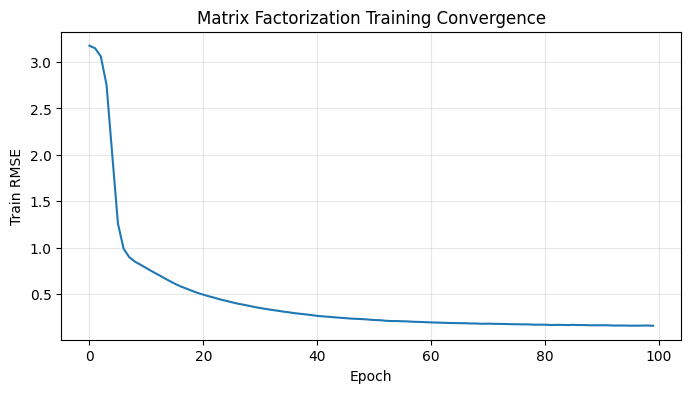

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title("Matrix Factorization Training Convergence")
plt.xlabel("Epoch")
plt.ylabel("Train RMSE")
plt.grid(alpha=0.3)
plt.show()


## 6. Evaluate on held-out test ratings

In [6]:
predicted_matrix = P @ Q.T
predicted_matrix = np.clip(predicted_matrix, 1, 5)

test_true = np.array([ratings_matrix[u, i] for u, i in test_idx])
test_pred = np.array([predicted_matrix[u, i] for u, i in test_idx])

test_rmse = np.sqrt(np.mean((test_true - test_pred) ** 2))
test_mae = np.mean(np.abs(test_true - test_pred))

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")


Test RMSE: 0.9040
Test MAE:  0.7289


In [7]:
# Baseline comparison: predicting the global average rating for every entry
global_avg = np.nanmean(ratings_matrix)
baseline_rmse = np.sqrt(np.mean((test_true - global_avg) ** 2))
print(f"Baseline (global average) RMSE: {baseline_rmse:.4f}")
print(f"Matrix Factorization RMSE:      {test_rmse:.4f}")
print(f"Improvement over baseline: {(1 - test_rmse/baseline_rmse):.1%}")


Baseline (global average) RMSE: 0.9418
Matrix Factorization RMSE:      0.9040
Improvement over baseline: 4.0%


## 7. Generate top-N recommendations for a sample user

In [8]:
def recommend_for_user(user_idx, ratings_matrix, predicted_matrix, movie_titles, n=5):
    """Recommend the top-N highest-predicted, not-yet-rated movies for a given user."""
    already_rated = ~np.isnan(ratings_matrix[user_idx])
    scores = predicted_matrix[user_idx].copy()
    scores[already_rated] = -np.inf  # exclude movies already rated

    top_n_idx = np.argsort(scores)[::-1][:n]
    recommendations = pd.DataFrame({
        "movie": [movie_titles[i] for i in top_n_idx],
        "predicted_rating": [round(scores[i], 2) for i in top_n_idx]
    })
    return recommendations

sample_user = 0
print(f"Top 5 recommendations for User_{sample_user + 1}:\n")
recommend_for_user(sample_user, ratings_matrix, predicted_matrix, movie_titles, n=5)


Top 5 recommendations for User_1:



,movie,predicted_rating
0,Movie_26,4.26
1,Movie_16,3.64
2,Movie_19,3.62
3,Movie_13,3.58
4,Movie_15,3.13


## 8. Conclusion

- The matrix factorization model learns latent user/item factors and substantially
  outperforms the naive global-average baseline on held-out ratings (lower RMSE).
- The learned model can generate personalized top-N recommendations for any user by
  ranking their predicted ratings on unseen items.

**Possible improvements:**
- Use a real-world dataset such as MovieLens for validation against known benchmarks.
- Compare against library implementations (e.g. the `surprise` package's SVD) for a sanity check.
- Add bias terms (user bias, item bias, global bias) to the factorization model for improved accuracy.
- Experiment with different numbers of latent factors and regularization strengths via grid search.
